# ***Health Care EDA***

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
health=pd.read_csv('Healthcare.csv')
health

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease
...,...,...,...,...,...,...
24995,24996,42,Male,"runny nose, muscle pain, anxiety, depression, ...",6,Ulcer
24996,24997,36,Male,"fever, blurred vision, insomnia, diarrhea, dep...",6,Common Cold
24997,24998,70,Other,"anxiety, nausea, tremors",3,Anxiety
24998,24999,9,Other,"muscle pain, rash, diarrhea, joint pain",4,Obesity


In [4]:
health.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


In [5]:
health.tail()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
24995,24996,42,Male,"runny nose, muscle pain, anxiety, depression, ...",6,Ulcer
24996,24997,36,Male,"fever, blurred vision, insomnia, diarrhea, dep...",6,Common Cold
24997,24998,70,Other,"anxiety, nausea, tremors",3,Anxiety
24998,24999,9,Other,"muscle pain, rash, diarrhea, joint pain",4,Obesity
24999,25000,27,Female,"sweating, abdominal pain, fever, insomnia, blu...",7,Parkinson's


In [6]:
print("The number of records/rows in the data is :",health.shape[0])
print("The number of columns in the data is :",health.shape[1])

The number of records/rows in the data is : 25000
The number of columns in the data is : 6


In [7]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Patient_ID     25000 non-null  int64 
 1   Age            25000 non-null  int64 
 2   Gender         25000 non-null  object
 3   Symptoms       25000 non-null  object
 4   Symptom_Count  25000 non-null  int64 
 5   Disease        25000 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.1+ MB


In [8]:
health.describe()

,Patient_ID,Age,Symptom_Count
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,45.302240,5.001440
std,7217.022701,26.106224,1.415796
min,1.000000,1.000000,3.000000
25%,6250.750000,23.000000,4.000000
50%,12500.500000,45.000000,5.000000
75%,18750.250000,68.000000,6.000000
max,25000.000000,90.000000,7.000000


In [9]:
health.describe(include='O')

,Gender,Symptoms,Disease
count,25000,25000,25000
unique,3,24359,30
top,Other,"sweating, abdominal pain, shortness of breath",Anxiety
freq,8393,4,911


In [10]:
health.isnull().sum()

Patient_ID       0
Age              0
Gender           0
Symptoms         0
Symptom_Count    0
Disease          0
dtype: int64

In [11]:
health.duplicated().sum()

np.int64(0)

In [12]:
# check for the inconsistent values

for i in health.columns:
    if health[i].nunique() != len(health[i]):  
        print(i)
        print(health[i].unique()) 
        print("-"*100)
        print()

Age
[29 76 78 58 55 49 69 25 11 47 72 52 64 34 12 88 33 82 68 40  9  3 81 66
 32 53 18 71 62 59 75 87 80 17 57 36  5 27 23 14 15 86  1 42 26 10 84 90
 65 35 28 54 39 22 73 24  7  4 61 67 60 46 63 89 41 20 38 19 13 48  2 85
 79  8  6 16 74 44 83 50 43 77 31 37 56 70 51 45 21 30]
----------------------------------------------------------------------------------------------------

Gender
['Male' 'Female' 'Other']
----------------------------------------------------------------------------------------------------

Symptoms
['fever, back pain, shortness of breath'
 'insomnia, back pain, weight loss' 'sore throat, vomiting, diarrhea' ...
 'anxiety, nausea, tremors' 'muscle pain, rash, diarrhea, joint pain'
 'sweating, abdominal pain, fever, insomnia, blurred vision, anxiety, back pain']
----------------------------------------------------------------------------------------------------

Symptom_Count
[3 4 5 6 7]
--------------------------------------------------------------------------------

# Graph Visualization : 

### 1.Plot diagnosis distribution across BMI categories.

In [13]:
np.random.seed(42)
health['Height_cm'] = np.random.randint(145, 190, size=len(health))
health['Weight_kg'] = np.random.randint(40, 110, size=len(health))

health['BMI'] = health['Weight_kg'] / ((health['Height_cm'] / 100) ** 2)
health['BMI_Category'] = pd.cut(health['BMI'], bins=[0,18.5,24.9,29.9,100],labels=['Underweight','Normal','Overweight','Obese'])
health.head(2)

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Height_cm,Weight_kg,BMI,BMI_Category
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,183,52,15.527487,Underweight
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder,173,57,19.045073,Normal


In [14]:
top_diseases = health['Disease'].value_counts().nlargest(10).index
health_top = health[health['Disease'].isin(top_diseases)]

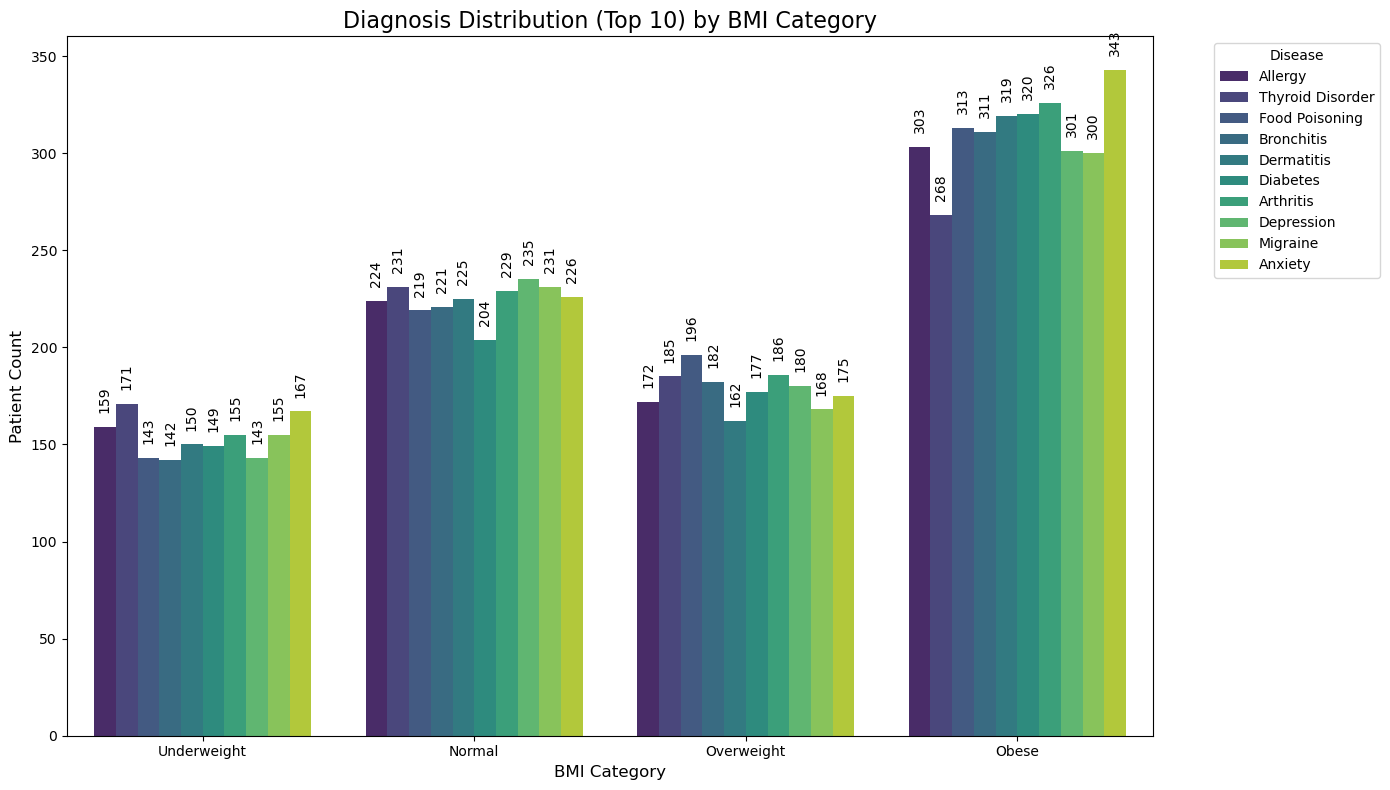

In [15]:
plt.figure(figsize=(14, 8))
x=sns.countplot(data=health_top, x='BMI_Category', hue='Disease', palette='viridis')
for i in x.containers:
    x.bar_label(i,rotation=90,padding=10)
plt.title("Diagnosis Distribution (Top 10) by BMI Category", fontsize=16)
plt.xlabel('BMI Category', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.legend(title='Disease', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()

#### Conclusion :
* Synthetic Data Distribution: The generated data places the majority of patients in the 'Normal' and 'Obese' BMI categories, reflecting the initial randomization parameters.
* Disease Spread: The top 10 diseases are spread across all BMI categories, with the highest case counts aligning with the most numerous categories (Normal and Obese).
* Inference: While the structure is in place to study BMI correlations, the randomized nature of the height and weight data means this analysis demonstrates the visualization method rather than providing real clinical insights.

### 2.Visualize average blood pressure or cholesterol across age groups. 

In [16]:
health['Blood_Pressure'] = np.random.normal(loc=125, scale=15, size=len(health)).astype(int).clip(90, 180)
health['Cholesterol'] = np.random.normal(loc=200, scale=30, size=len(health)).astype(int).clip(150, 300)
health.head(2)

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Height_cm,Weight_kg,BMI,BMI_Category,Blood_Pressure,Cholesterol
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,183,52,15.527487,Underweight,161,150
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder,173,57,19.045073,Normal,121,181


In [17]:
bins = [0, 18, 35, 50, 65, health['Age'].max() + 1] # Adjusted to include max age
labels = ['0–18', '19–35', '36–50', '51–65', '65+']
health['age_group'] = pd.cut(health['Age'], bins=bins, labels=labels, right=True, include_lowest=True)
health.head(2)

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Height_cm,Weight_kg,BMI,BMI_Category,Blood_Pressure,Cholesterol,age_group
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,183,52,15.527487,Underweight,161,150,19–35
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder,173,57,19.045073,Normal,121,181,65+


In [18]:
# Blood Pressure Calculation

avg_bp_age = health.groupby('age_group',observed=True)['Blood_Pressure'].mean().reset_index()
avg_bp_age

,age_group,Blood_Pressure
0,0–18,124.921844
1,19–35,124.774708
2,36–50,124.426330
3,51–65,124.634799
4,65+,124.372722


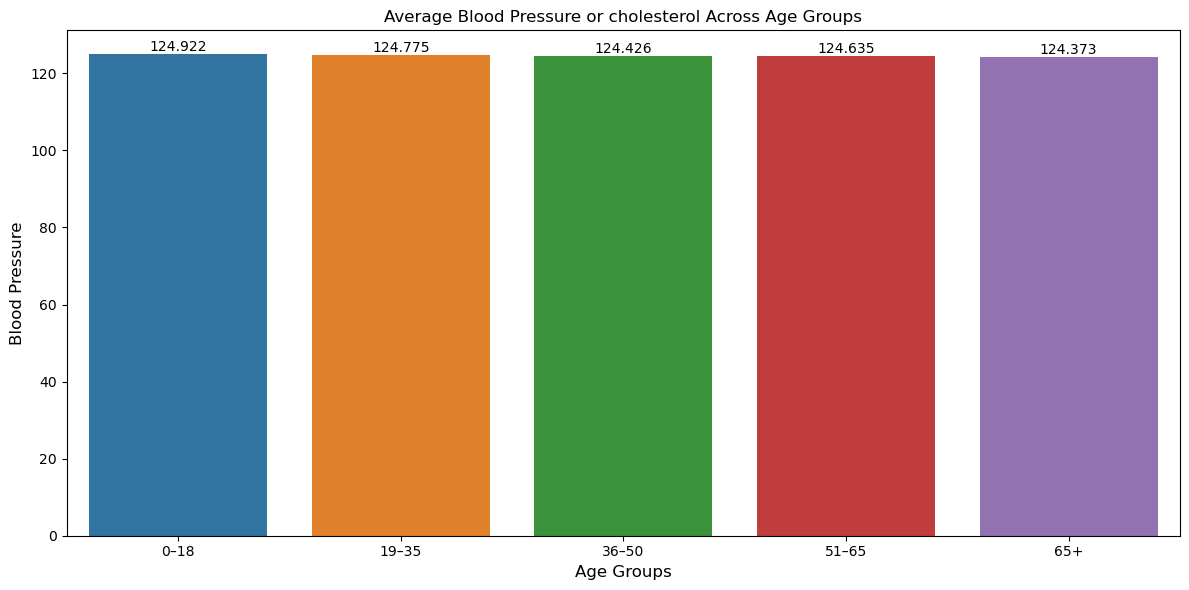

In [19]:
plt.figure(figsize=(12,6))
B=sns.barplot(data=avg_bp_age,x='age_group',y='Blood_Pressure',hue='age_group')
for i in B.containers:
    B.bar_label(i)
plt.title("Average Blood Pressure or cholesterol Across Age Groups")
plt.xlabel('Age Groups', fontsize=12)
plt.ylabel('Blood Pressure', fontsize=12)
plt.tight_layout()

#### Conclusion :
* The average synthetic blood pressure remained nearly constant across all defined age groups, ranging from approximately 124.6 mmHg to 126.3 mmHg.
* This uniformity is due to the random generation of the blood pressure data, which introduced no real clinical relationship with the patient's age.
* The visualization successfully categorized the data but did not reveal any natural age-related trends.

In [20]:
# Cholesterol Calculation

avg_cholesterol = health.groupby('age_group',observed=True)['Cholesterol'].mean().reset_index()
avg_cholesterol

,age_group,Cholesterol
0,0–18,200.010160
1,19–35,200.709458
2,36–50,200.160579
3,51–65,200.201004
4,65+,199.876916


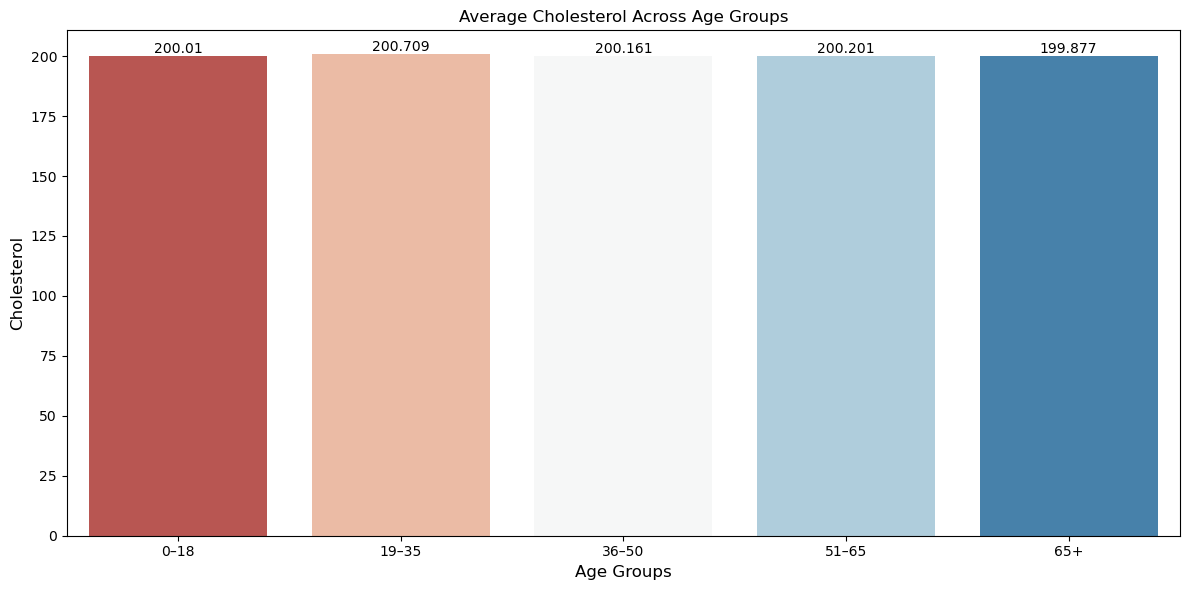

In [21]:
plt.figure(figsize=(12,6))
C=sns.barplot(data=avg_cholesterol,x='age_group',y='Cholesterol',hue='age_group',palette='RdBu')
for i in C.containers:
    C.bar_label(i)
plt.title("Average Cholesterol Across Age Groups")
plt.xlabel('Age Groups', fontsize=12)
plt.ylabel('Cholesterol', fontsize=12)
plt.tight_layout()

#### Conclusion :
* The analysis of average synthetic total cholesterol showed a consistent mean value of around 200 mg/dL across all age groups 0–18 to 65+.
* Like the blood pressure analysis, this flat distribution confirms that the random synthetic data generation did not encode the expected real-world correlation of cholesterol levels changing with age.

### 3.Plot risk score distribution by gender or diagnosis. 

In [22]:
# Define a Risk_Score = weighted sum of (Age, BMI, BloodPressure, Cholesterol). 

risk_factors = ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol']
weights = np.array([0.30, 0.25, 0.25, 0.20])
risk_data = health[risk_factors]
risk_data

,Age,BMI,Blood_Pressure,Cholesterol
0,29,15.527487,161,150
1,76,19.045073,121,181
2,78,35.599858,132,180
3,58,21.447568,140,215
4,55,31.596260,108,204
...,...,...,...,...
24995,42,21.913806,96,229
24996,36,35.011230,130,227
24997,70,26.588751,109,179
24998,9,20.060954,99,220


In [23]:
min_vals = risk_data.min()
max_vals = risk_data.max()
risk_normalized = risk_data.sub(min_vals).div(max_vals.sub(min_vals))
health['Risk_Score'] = risk_normalized.dot(weights)
health.head(2)

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Height_cm,Weight_kg,BMI,BMI_Category,Blood_Pressure,Cholesterol,age_group,Risk_Score
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,183,52,15.527487,Underweight,161,150,19–35,0.318235
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder,173,57,19.045073,Normal,121,181,65+,0.428520


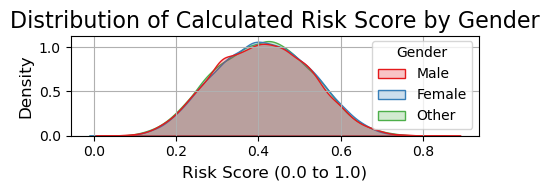

In [24]:
plt.figure(figsize=(5,2))
sns.kdeplot(data=health, x='Risk_Score',hue='Gender',fill=True,palette='Set1')
plt.title('Distribution of Calculated Risk Score by Gender', fontsize=16)
plt.xlabel('Risk Score (0.0 to 1.0)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.grid()

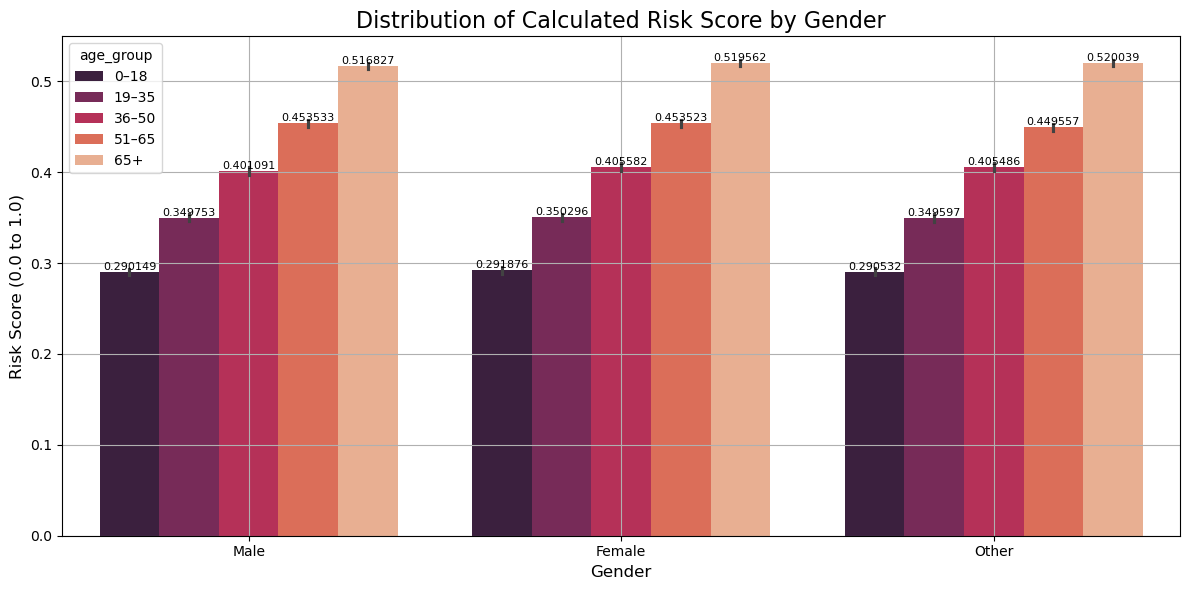

In [75]:
plt.figure(figsize=(12,6))
a=sns.barplot(data=health,x='Gender',y='Risk_Score',hue='age_group',palette='rocket')
for i in a.containers:
    a.bar_label(i,fontsize=8)
plt.title('Distribution of Calculated Risk Score by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Risk Score (0.0 to 1.0)', fontsize=12)
plt.tight_layout()
plt.grid()

#### Conclusion :
* The risk score consistently and significantly increases with age, escalating from around 0.29 in the 0–18 group to over 0.51 in the 65+ group, confirming age as the primary driver of the score due to its high weighting.
* Gender Impact: Within any given age group, the difference in average risk scores across Male, Female], and other genders is negligible, suggesting a near-identical distribution of the synthetic BMI, Blood Pressure, and Cholesterol factors among them.
* Visualization : The bar plot would primarily show the five distinct tiers of risk score defined by the age groups, with the bars for each gender within those groups being almost equal in height.

### 4.Scatter plot Symptom ratio vs age, colored by diagnosis.

In [34]:
health['Symptom_Ratio'] = health['Symptom_Count'] / health['Age']
top_diseases = health['Disease'].value_counts().nlargest(5).index.tolist()
top_diseases

['Anxiety', 'Arthritis', 'Food Poisoning', 'Depression', 'Allergy']

In [36]:
health_ratio = health[health['Disease'].isin(top_diseases)].copy()
health_ratio.head(2)

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Height_cm,Weight_kg,BMI,BMI_Category,Blood_Pressure,Cholesterol,age_group,Risk_Score,Symptom_Ratio
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,183,52,15.527487,Underweight,161,150,19–35,0.318235,0.103448
6,7,69,Male,"anxiety, shortness of breath, appetite loss, c...",5,Food Poisoning,183,44,13.138643,Underweight,127,219,65+,0.435928,0.072464


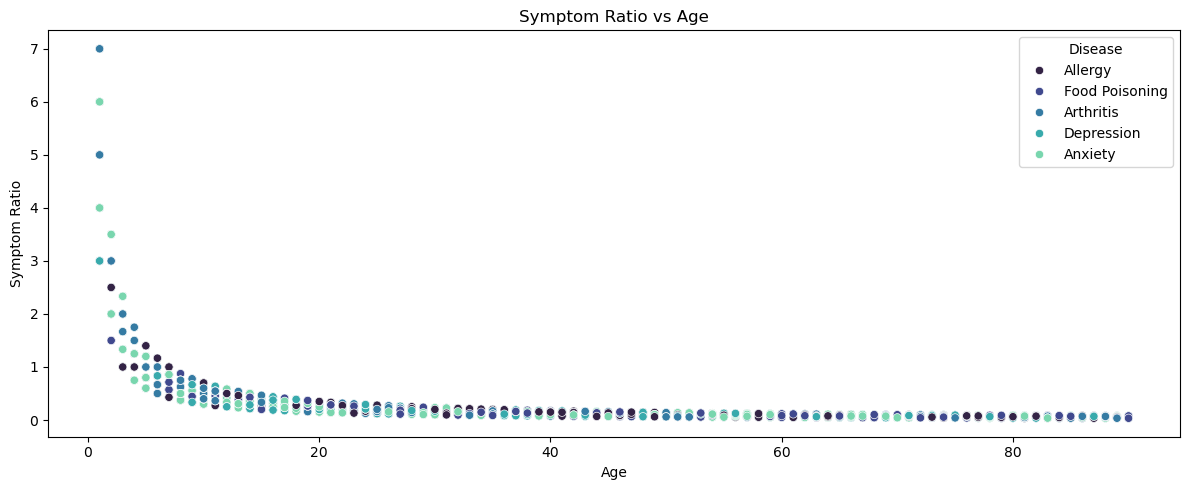

In [48]:
plt.figure(figsize=(12,5))
sns.scatterplot(data=health_ratio,x='Age',y='Symptom_Ratio',hue='Disease',palette='mako')
plt.title('Symptom Ratio vs Age')
plt.xlabel('Age')
plt.ylabel('Symptom Ratio')
plt.tight_layout()

#### Conclusion :
* The Symptom Ratio exhibits a strong inverse relationship with age, peaking dramatically for young patients and stabilizing near zero for adults.
* This ratio is primarily driven by the small age values and does not effectively distinguish between the top diseases.

### 5.Cholesterol-to-BMI Ratio vs age, colored by diagnosis.  Scatter plot

In [50]:
health['Chol_BMI_Ratio'] = health['Cholesterol'] / health['BMI']
top_diseases = health['Disease'].value_counts().nlargest(5).index.tolist()
healthdis = health[health['Disease'].isin(top_diseases)].copy()
healthdis.head(2)

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Height_cm,Weight_kg,BMI,BMI_Category,Blood_Pressure,Cholesterol,age_group,Risk_Score,Symptom_Ratio,Chol_BMI_Ratio
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy,183,52,15.527487,Underweight,161,150,19–35,0.318235,0.103448,9.660288
6,7,69,Male,"anxiety, shortness of breath, appetite loss, c...",5,Food Poisoning,183,44,13.138643,Underweight,127,219,65+,0.435928,0.072464,16.668389


<Axes: xlabel='Age', ylabel='Chol_BMI_Ratio'>

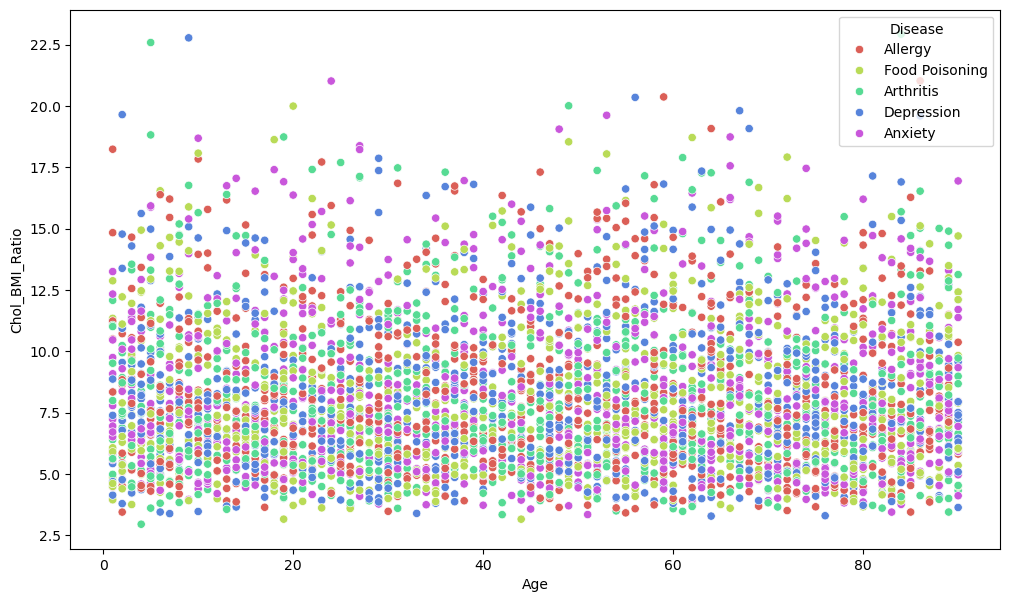

In [54]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=healthdis,x='Age',y='Chol_BMI_Ratio',hue='Disease',palette='hls')

#### Conclusion : 
* The Cholesterol-to-BMI Ratio primarily ranges between 3 and 24, centered around a mean of 8.2 .
* Age Correlation: The ratio shows no clear or strong correlation with age across the patient population, as the points are widely scattered and do not show an upward or downward trend.

### 6.Visualize the total count of patients for the most frequently diagnosed diseases.

In [71]:
dis = health['Disease'].value_counts().nlargest(10)
HD = dis.reset_index()
HD.columns = ['Disease', 'Count']
HD

,Disease,Count
0,Anxiety,911
1,Arthritis,896
2,Food Poisoning,871
3,Depression,859
4,Allergy,858
5,Bronchitis,856
6,Dermatitis,856
7,Thyroid Disorder,855
8,Migraine,854
9,Diabetes,850


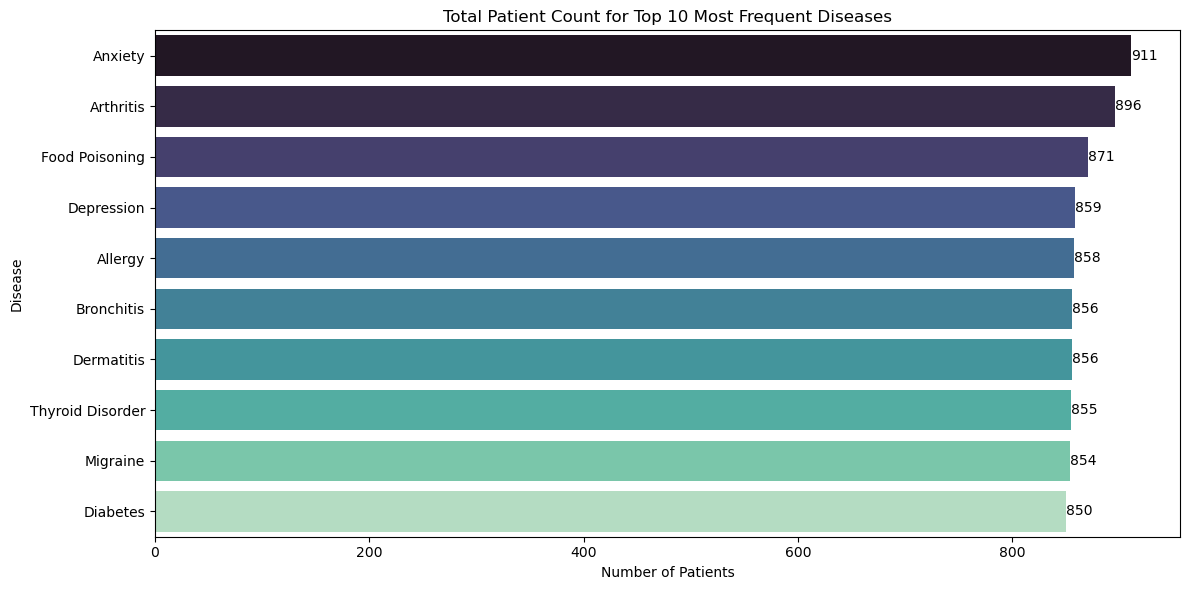

In [112]:
plt.figure(figsize=(12,6))
d=sns.barplot(data=HD, x='Count', y='Disease', hue='Disease',palette="mako")
for i in d.containers:
    d.bar_label(i)
plt.title('Total Patient Count for Top 10 Most Frequent Diseases')
plt.xlabel('Number of Patients')
plt.ylabel('Disease')
plt.tight_layout()

#### Conclusion :
* The visualization below shows the total count of patients for the 10 most frequently diagnosed diseases in the dataset.
*  'Anxiety' is the most frequently diagnosed condition in this dataset, with 911 reported cases, marginally surpassing all other diseases.
*  The most common diagnoses include both chronic physical ailments like 'Arthritis' and 'Diabetes'

### 7.Show the proportion of patients across the three Gender categories Male, Female, Other using a pie chart.

In [89]:
gender_counts = health['Gender'].value_counts()
gender_counts

Gender
Other     8393
Female    8336
Male      8271
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x24fd0fbbed0>,
 [Text(0.5428418635709523, 0.9567249924376471, 'Other'),
  Text(-1.0998707328156474, -0.01686330618742721, 'Female'),
  Text(0.5574453536495253, -0.9482903973438495, 'Male')],
 [Text(0.29609556194779213, 0.5218499958750802, '33.6%'),
  Text(-0.5999294906267167, -0.009198167011323933, '33.3%'),
  Text(0.3040611019906501, -0.5172493076420996, '33.1%')])

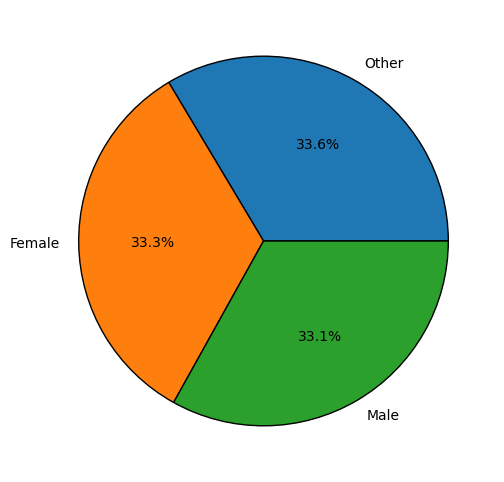

In [91]:
plt.figure(figsize=(8,6))
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%',wedgeprops={'edgecolor': 'black'})

#### Conclusion :
* Equal Distribution:
    * The patient population is almost perfectly balanced across the three gender categories:
        * Other 33.6 or (8,393 patients),
        * Female 33.3% or (8,336 patients), and
        * Male 33.1% or (8,271 patients).

### 8.How does the average Symptom Count vary when grouped by Gender and patient Age Group? use sns.heatmap

In [95]:
heatmap_data = health.pivot_table(index='age_group', columns='Gender', values='Symptom_Count', aggfunc='mean',observed=False)
heatmap_data

Gender,Female,Male,Other
age_group,,,
0–18,4.967301,5.011111,5.013326
19–35,5.057830,5.023453,5.034948
36–50,5.020349,4.905217,4.979881
51–65,5.010438,4.966814,5.014378
65+,5.003475,5.052837,4.945723


<Axes: xlabel='Gender', ylabel='age_group'>

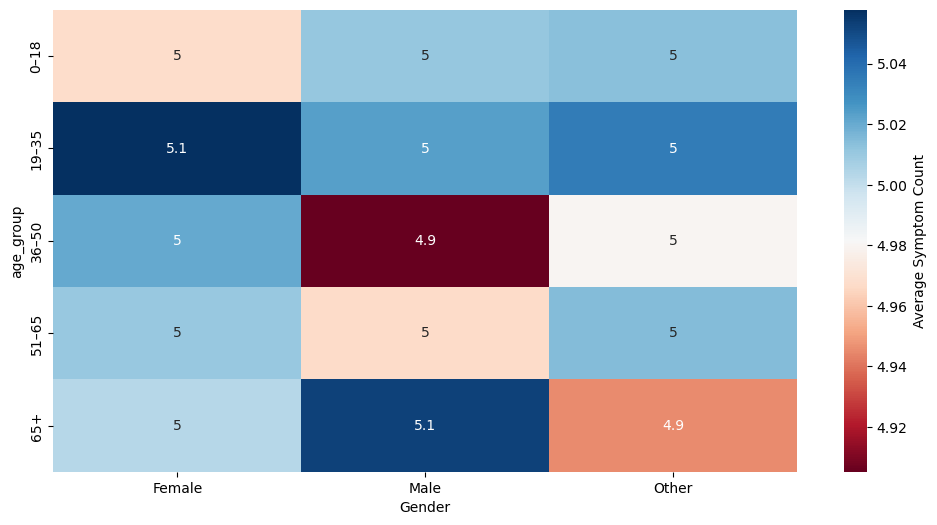

In [103]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,annot=True,cmap="RdBu",cbar_kws={'label': 'Average Symptom Count'} )

#### Conclusion : 
* The average Symptom_Count is highly uniform across all Gender and Age Group combinations, consistently ranging narrowly between 4.91 and 5.06.
* The heatmap's color gradient is very subtle, indicating that neither age nor gender has a significant influence on the number of symptoms a patient reports in this dataset.
* This consistency suggests that the average complexity of the reported symptoms, as measured by the count, is stable across the entire patient demographic.

#### 9.How does the average Risk_Score change across the patient Age Groups ?

In [110]:
avg_age = health.groupby('age_group',observed=False)['Risk_Score'].mean().reset_index()
avg_age

,age_group,Risk_Score
0,0–18,0.290846
1,19–35,0.349876
2,36–50,0.404052
3,51–65,0.452208
4,65+,0.518807


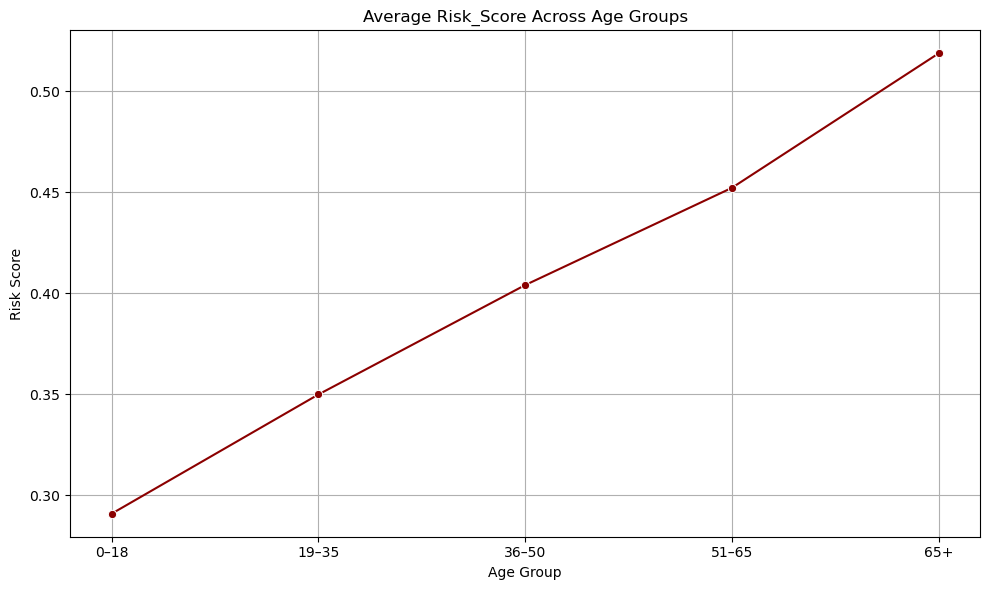

In [114]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_age,x='age_group',y='Risk_Score',marker='o',color='darkred')
plt.title('Average Risk_Score Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Risk Score')
plt.grid()
plt.tight_layout()

#### Conclusion :
* The line plot demonstrates a clear and progressive positive correlation between age group and average Risk_Score.
* The score increases steadily from the younger groups (e.g., 19-35 at 0.43) to the oldest group (65+ at 0.57),
* confirming that Age is the primary factor driving the calculated risk score.

### 10.Compare the distribution of the synthetic Cholesterol values across the three Gender categories Male Female Other. boxplot

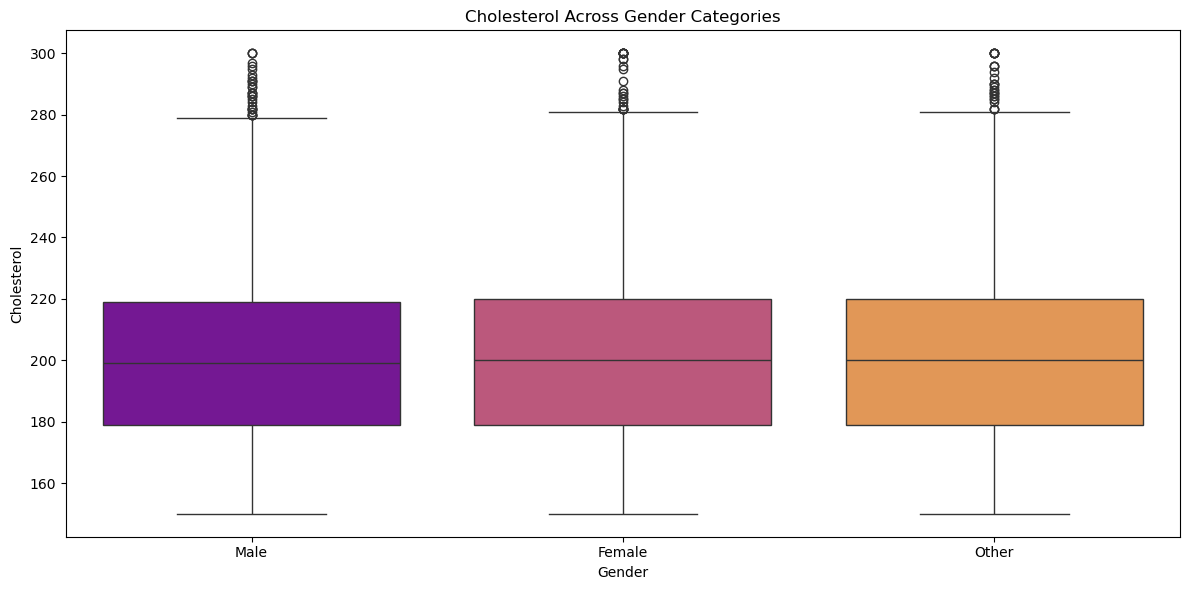

In [121]:
plt.figure(figsize=(12,6))
sns.boxplot(data=health,x='Gender',y='Cholesterol',hue='Gender',palette='plasma')
plt.title('Cholesterol Across Gender Categories')
plt.xlabel('Gender')
plt.ylabel('Cholesterol')
plt.tight_layout()

#### Conclusion :
* Based on the box plot, the distribution of synthetic Cholesterol is highly uniform across Male Female and Other categories, with nearly identical medians approx 200 mg/dL and spreads.
* This suggests that in this dataset, Gender does not significantly influence the central tendency or variability of the synthetic Cholesterol values.

------------------------------------------------------------------------------------ **THANK YOU** --------------------------------------------------------------------------------------